# Исследование продаж на черную пятницу

Цель исследования - ответить на вопросы:

    1. Есть ли зависимость между полом покупателя и средним чеком?
    2. Есть ли зависимость между возрастом и средним чеком?
    3. А так же выделить сегмент типичного покупателя.

**Ход исследования**

О качестве данных ничего не известно. Поэтому перед тем, как отвечать на вопрсы исследования и делать вывод, понадобится обзор данных.

Проверим данные на ошибки и оценим их влияние на исследование. Затем, на этапе предобработки, поищем возможность исправить самые критичные ошибки данных.

После ответа на поставленные вопросы, сделаем общий вывод.

Таким образом, исследование пройдёт в пять этапов:

  1. Обзор данных
  2. Предобработка данных
  3. Добавление новых колонок в таблицу
  4. Ответы на вопросы исследования
  5. Общий вывод

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# читаем данные с помощью pandas и сохраняем в переменную df
df = pd.read_csv('train.csv')

# Обзор данных

In [3]:
# обзор данных, получаем 5 случайных строк
df.sample(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
101189,1003654,P00251242,M,26-35,17,B,3,1,5,11.0,NaN,8832
435130,1001019,P00319342,M,36-45,1,A,4+,1,5,8.0,NaN,7055
251902,1002887,P00221442,M,26-35,3,B,3,1,1,2.0,5.0,11890
167757,1001886,P00361842,M,26-35,12,C,3,0,15,16.0,NaN,13202
340910,1004447,P00298142,M,46-50,5,B,0,1,5,8.0,NaN,5150


In [4]:
# обзор df, получаем общую информацию
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


В таблице 2 колонки с типом `float64`, 5 колонок с типом `int64` и 5 колонок с типом `object`. Всего в датафрейме 550068 строк.

Согласно описанию с kaggle:
* `User_ID` - id пользователя
* `Product_ID` - id продукта
* `Gender` - пол 
* `Age` - возраст
* `Occupation` - профессия 
* `City_Category` - город
* `Stay_In_Current_City_Years` - количество лет проживания в городе
* `Marital_Status` - семейное положение
* `Product_Category_1` - категория продуктов 1
* `Product_Category_2` - категория продуктов 2
* `Product_Category_3` - категория продуктов 3
* `Purchase` - сумма покупки

Названия колонок написаны с заглавных букв, нужно будет перевести их в нижний регистр для удобства.

В колонках `Product_Category_2` и `Product_Category_3` значений меньше, чем в других колонках. То есть в данных встречается пропуки. Из-за этого формат колонок `float64`, а не `int64`.

In [5]:
# описательная статистика каждой колонки
df.describe(include='all')

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
unique,NaN,3631,2,7,NaN,3,5,NaN,NaN,NaN,NaN,NaN
top,NaN,P00265242,M,26-35,NaN,B,1,NaN,NaN,NaN,NaN,NaN
freq,NaN,1880,414259,219587,NaN,231173,193821,NaN,NaN,NaN,NaN,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,NaN,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,NaN,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,NaN,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,NaN,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,NaN,1.000000,8.000000,15.000000,16.000000,12054.000000


В колонка `Purchase` минимальное значение 12 очень маленькое. Однозначно говорить про аномалию или ошибку нельзя. Нужно подробнее посмотреть на данные.

In [6]:
# посмотрим количество уникальных значений в колонках
columns = ['User_ID', 'Occupation', 'Marital_Status',
          'Product_Category_1', 'Product_Category_2', 'Product_Category_3']

for i in columns:
    print(f'Количество уникальных значений в колонке {i}: {df[i].nunique()}')

Количество уникальных значений в колонке User_ID: 5891
Количество уникальных значений в колонке Occupation: 21
Количество уникальных значений в колонке Marital_Status: 2
Количество уникальных значений в колонке Product_Category_1: 20
Количество уникальных значений в колонке Product_Category_2: 17
Количество уникальных значений в колонке Product_Category_3: 15


#### Выводы

В таблице находятся данные покупок 5891 уникальных пользоваетелей в период черной пятницы.

Названия колонок написаны с заглавных букв. В 2-ух колонках отмечено несоответсвие типов данных. В данных присутствуют пропуски. В колонке `Purchase` отмечены аномальные значения.

# Предобработка данных

### Исправление название колонок

In [7]:
df.columns = df.columns.str.lower()

# проверка названия колонок
df.columns

Index(['user_id', 'product_id', 'gender', 'age', 'occupation', 'city_category',
       'stay_in_current_city_years', 'marital_status', 'product_category_1',
       'product_category_2', 'product_category_3', 'purchase'],
      dtype='object')

#### Вывод

Изменен стиль именования колонок в нижний регистр для удобства.

###  Обработка пропусков

In [8]:
df.isna().sum()

user_id                            0
product_id                         0
gender                             0
age                                0
occupation                         0
city_category                      0
stay_in_current_city_years         0
marital_status                     0
product_category_1                 0
product_category_2            173638
product_category_3            383247
purchase                           0
dtype: int64

Пропуски втречаются в колонках `product_category_2` и `product_category_3`. Объем пропусков существенный - 31% и 70% соответственно. Возможно это специфические категории, которые не так часто покупаю в период больших скидок. Заменить их параметрами выборки или выбросить из датасета невозможно. 

Изменить тип колонок с `float` на `int` не получится из-за пропусков.

#### Вывод

Пропуски оставляем как есть. На результат исследования это не повлияет.

### Аномальные значения

В колонке `purchase` присутствует минимальное значение 12 при среднем 9263 и стандартном отклонении 5023. Посмотрим на это более подробно.

In [9]:
# строка с суммой покупки равной 12
df[df['purchase'] == 12].sample(10)

,user_id,product_id,gender,age,occupation,city_category,stay_in_current_city_years,marital_status,product_category_1,product_category_2,product_category_3,purchase
549675,1005470,P00370853,M,55+,7,C,3,0,19,NaN,NaN,12
547555,1002429,P00370293,M,26-35,2,A,2,1,19,NaN,NaN,12
547885,1002896,P00370853,M,18-25,14,B,0,0,19,NaN,NaN,12
549986,1005918,P00370853,M,26-35,12,A,3,1,19,NaN,NaN,12
546016,1000155,P00370293,M,36-45,12,C,4+,1,19,NaN,NaN,12
547559,1002437,P00370853,M,26-35,4,C,4+,1,19,NaN,NaN,12
548701,1004094,P00370293,M,26-35,17,C,3,0,19,NaN,NaN,12
549743,1005570,P00370853,M,26-35,1,B,3,0,19,NaN,NaN,12
546325,1000598,P00370293,M,36-45,7,C,1,1,19,NaN,NaN,12
549036,1004566,P00370293,M,36-45,17,C,1,0,19,NaN,NaN,12


In [10]:
# посмотрим на уникальные значения колонок product_category_1, _2, _3 при сумме равной 12
(
    df[df['purchase'] == 12]['product_category_1'].unique(),
    df[df['purchase'] == 12]['product_category_2'].unique(),
    df[df['purchase'] == 12]['product_category_3'].unique()
)

(array([19]), array([nan]), array([nan]))

In [11]:
# посмотрим на количество строк при сумме равной 12
df[df['purchase'] == 12].shape

(101, 12)

#### Вывод

В данных присутствует колонка `purchase` со средним 9263, стандартным отклонением 5023 и минимальным значением 12.

Обзор данных показал, что 12 не является аномальным значением. Всего таких значений в данных 101. Встречаются они только в колонке `product_category_1` и только при покупки категории `19`.

### Обработка дубликатов

In [12]:
# Проверим таблицу на наличие строковых дубликатов
df.duplicated().sum()

0

#### Вывод

Явных дубликатов в талице отсутствует.

# Добавление новых колонок в таблицу

Рассчитаем и добавим в таблицу данные, которые потребуются для решения задач исследования.

* `purchase_quantity` - количество покупок одного пользователя из разных категорий товаров

#### Колонка purchase_quantity

In [13]:
columns = ['product_category_1',
          'product_category_2',
          'product_category_3']

# подсчет количества покупок из разных категорий
df['purchase_quantity'] = df[columns].fillna(0).astype('bool').sum(axis=1)

In [14]:
# проверка правильности подсчетов
df.sample(5)

,user_id,product_id,gender,age,occupation,city_category,stay_in_current_city_years,marital_status,product_category_1,product_category_2,product_category_3,purchase,purchase_quantity
330442,1002934,P00022442,F,36-45,20,B,3,0,8,16.0,NaN,5948,2
254277,1003272,P00209742,M,36-45,0,B,1,0,1,11.0,15.0,15729,3
453552,1003824,P00014842,M,26-35,17,A,3,1,1,2.0,5.0,11421,3
248336,1002203,P00182242,M,46-50,12,B,4+,1,1,5.0,6.0,11601,3
549502,1005221,P00375436,F,55+,1,C,1,0,20,NaN,NaN,123,1


#### Вывод

В таблицу было добавлена колонка `purchase_quantity`, которая показывает количество покупок из разных категорий. Данная колонка добавит информации про типичного покупателя.

# Ответы на вопросы исследования

### Есть ли зависимость между полом покупателя и средним чеком?

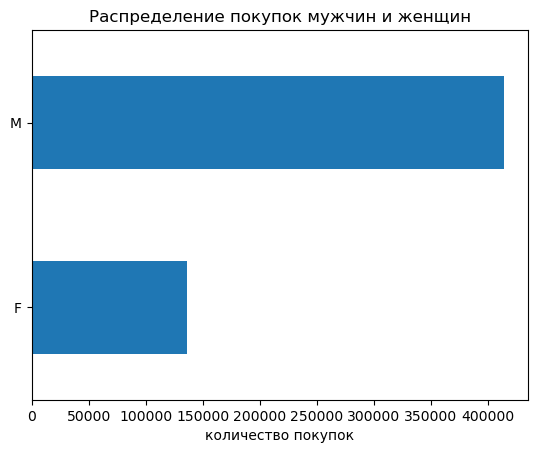

In [15]:
# для начала посмотрим распределение покупок мужчин и женщин в выборке
df['gender'].value_counts().sort_values().plot(kind='barh')

plt.title('Распределение покупок мужчин и женщин')
plt.xlabel('количество покупок')
plt.ylabel('')

plt.show()

Видно явное преимущество по количеству покупок за мужчинами, в цыфрах это 75% против 25%.

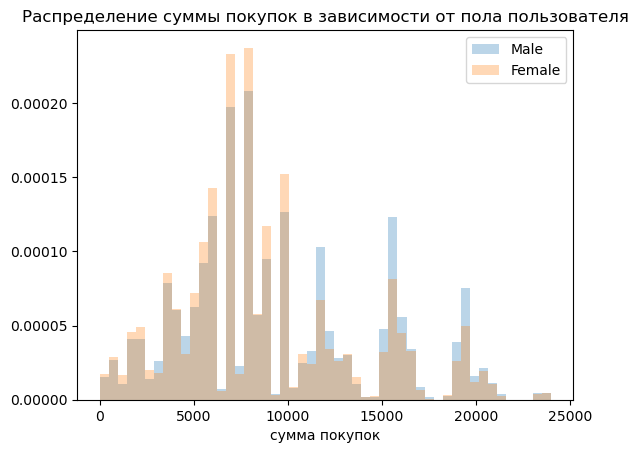

In [16]:
# посмотрим на распределение суммы покупок в зависимости от пола пользователя
M = df[df['gender'] == 'M']['purchase']
F = df[df['gender'] == 'F']['purchase']

fig, ax = plt.subplots()

ax.hist(M, bins=50, alpha=0.3, label='Male', density=True)
ax.hist(F, bins=50, alpha=0.3, label='Female', density=True)

plt.legend()
plt.title('Распределение суммы покупок в зависимости от пола пользователя')
plt.xlabel('сумма покупок')
plt.ylabel('')

plt.show()

На графике можно заметить что женщины совершили больше покупок на сумму <10000 уе., тогда как у мужчин больше покупок на сумму >10000 уе.

In [17]:
# посмотрим на количество покупок совершенных из разных категорий
report = df.pivot_table(index='purchase_quantity', 
                        columns='gender', 
                        values='user_id', 
                        aggfunc='count') \
                        .apply(lambda x: x / (x.sum())).round(3)
report.columns = ['Female', 'Male']

report

,Female,Male
purchase_quantity,,
1,0.326,0.312
2,0.397,0.376
3,0.277,0.312


Женщины чаще покупаю товары одной или двух категорий, тогда как мужчины чаще покупают сразу три категории товаров во время больших скидок.

In [18]:
# посмотрим на средний чек при покупки разного количества товаров
report = pd.crosstab(index=df['gender'], 
                     columns=df['purchase_quantity'],
                     values=df['purchase'],
                     aggfunc='mean').round(2)
report.index = ['Female', 'Male']

report

purchase_quantity,1,2,3
Female,7422.20,8173.87,11084.72
Male,7551.73,9022.74,11824.92


При покупке только одной категории товаров, средний чек женщины и мужчины одинаковый, 7422 и 7551 соответственно. При покупке двух категории товаров, средний чек женщины меньше чем у мужчины на 849 уе. При покупке трех категории товаров, средний чек женщины меньше чем у мужчины на 740 уе.

#### Выводы

Установлена зависимость между полом покупателя и средним чеком.

**Если клиент мужского пола, его средний чек будет больше, чем у женщины.** При покупке одной категории, средний чек будет равен. При покупке двух категорий, средний чек мужчины будет больше, 9022 против 8173. При покупке трех категорий, средний чек мужчины будет больше, 11824 против 11084.

Во время больших скидок мужчины совершаю покупки в 3 раза чаще чем женщины.

### Есть ли зависимость между возрастом и средним чеком?

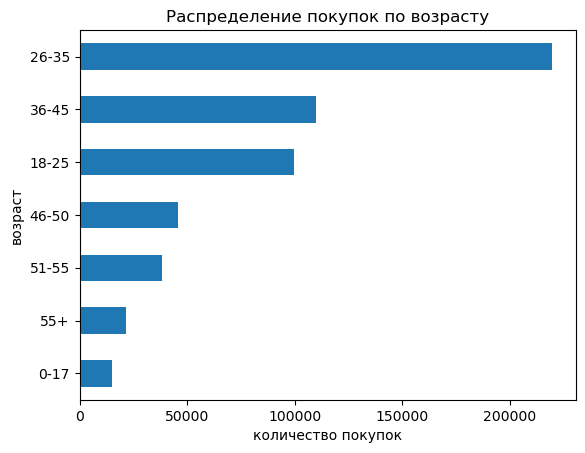

In [19]:
# для начала посмотрим распределение покупок по возросту
df['age'].value_counts().sort_values().plot(kind='barh')

plt.title('Распределение покупок по возрасту')
plt.xlabel('количество покупок')
plt.ylabel('возраст')

plt.show()

* больше всего сделали покупок пользователи в возрасте 26-35 лет
* меньше всего 0-17 лет и 55+
* пользователи в возрасте 36-45 и 18-25 совершили примерно одинаковое количество покупок
* пользователи в возрасте 46-50 и 51-55 совершили примерно одинаковое количество покупок

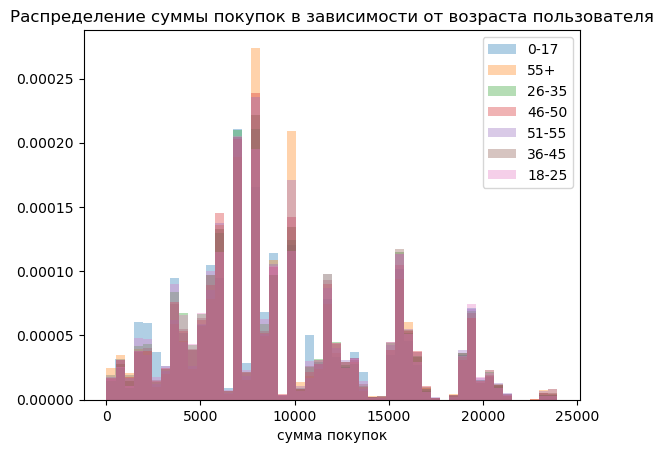

In [20]:
# посмотрим на распределение суммы покупок в зависимости от возраста пользователя
fig, ax = plt.subplots()

for i in df['age'].unique():
    ax.hist(df[df['age'] == i]['purchase'], bins=50, alpha=0.35, label=i, density=True)
    
plt.legend()
plt.title('Распределение суммы покупок в зависимости от возраста пользователя')
plt.xlabel('сумма покупок')
plt.ylabel('')

plt.show()

На графике можно отметить большую частоту покупок товаров <4000 и 10000-14000 от пользователей в возрасте 0-17. Пользовател в возрасте 55+ больше совершаю покупок на сумму 7011 и 10081.

In [21]:
# посмотрим на количество покупок совершенных из разных категорий
report = df.pivot_table(index='purchase_quantity', 
                        columns='age', 
                        values='user_id', 
                        aggfunc='count') \
                        .apply(lambda x: x / (x.sum())).round(3)

report

age,0-17,18-25,26-35,36-45,46-50,51-55,55+
purchase_quantity,,,,,,,
1,0.295,0.306,0.316,0.315,0.321,0.324,0.345
2,0.382,0.380,0.379,0.382,0.386,0.386,0.382
3,0.323,0.314,0.305,0.303,0.293,0.290,0.273


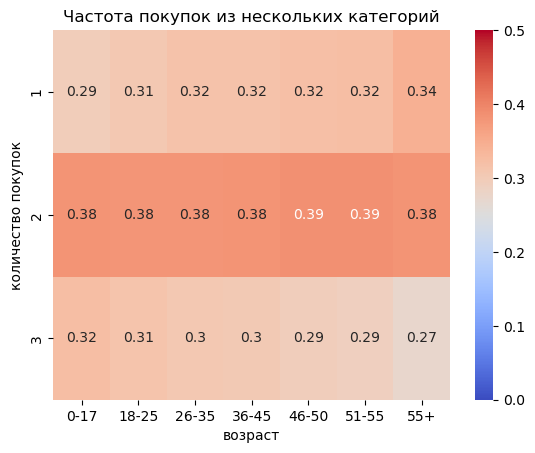

In [22]:
sns.heatmap(report, vmin=0, vmax=0.5,
           cmap='coolwarm', annot=True)

plt.title('Частота покупок из нескольких категорий')
plt.xlabel('возраст')
plt.ylabel('количество покупок')

plt.show()

Можно отметичть, что все пользователи с одинаковой частотой покупают товары из 2-х категорий. Пользователи в возрасте 0-17 чаще других покупают сразу 3 категории товаров. Пользователи в возрасте 55+ чаще других покупают товары только из 1-й категории.

In [23]:
# посмотрим на средний чек при покупке разного количества товаров
report = pd.crosstab(index=df['age'], 
                     columns=df['purchase_quantity'],
                     values=df['purchase'],
                     aggfunc='mean').astype('int')

report

purchase_quantity,1,2,3
age,,,
0-17,7186,8391,11172
18-25,7221,8744,11580
26-35,7495,8820,11612
36-45,7631,8834,11729
46-50,7663,8633,11663
51-55,7879,9045,12035
55+,7737,8977,11861


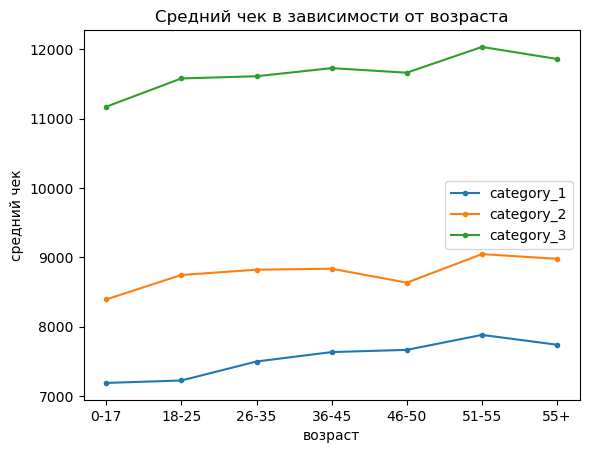

In [24]:
plt.plot(report, marker='.')
plt.legend(['category_1', 'category_2', 'category_3'])

plt.title('Средний чек в зависимости от возраста')
plt.xlabel('возраст')
plt.ylabel('средний чек')

plt.show()

##### Вывод

Установлена зависимость между возрастом покупателя и средним чеком.

Вне зависимости от количества покупаемых категорий товара, средний чек будет расти тем выше, чем старше пользователь.  

### Анализ сегмента покупателей в период черной пятницы

Выделим сегмент покупателя, который чаще всего встречается в данных.

Ранее мы видели, что чаще покупают мужчины в возрасте 26-35 лет, 2 категории товара. Дополним эту информают анализом колонок: `occupation`, `city_category`, `marital_status`.

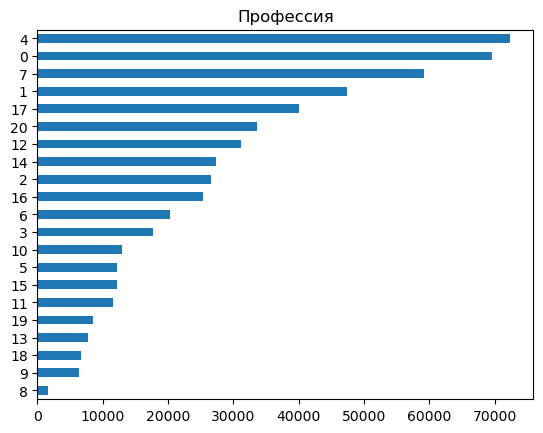

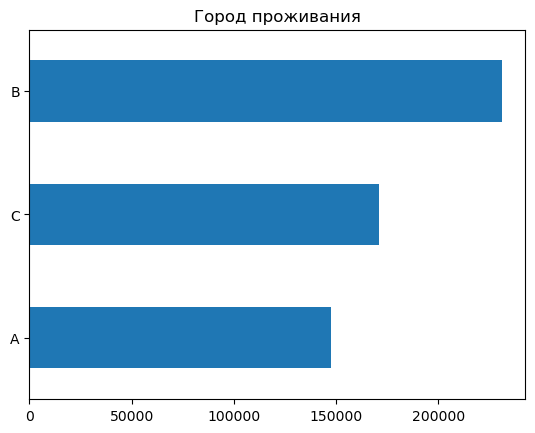

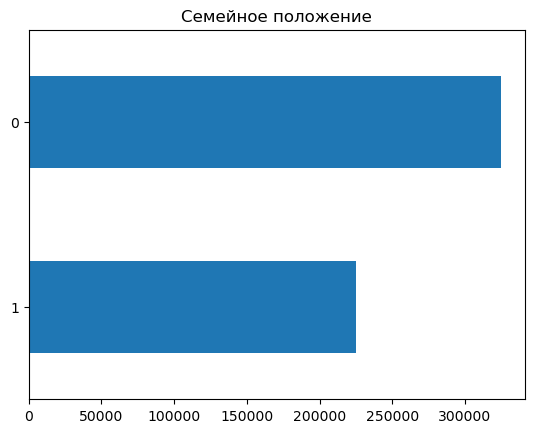

In [25]:
columns = {
    'occupation': 'Профессия',
    'city_category': 'Город проживания',
    'marital_status': 'Семейное положение'
}

for k, v in columns.items():
    (
        df[k].value_counts()
            .sort_values(ascending=True)
            .plot(kind='barh')
    )
    plt.title(v)
    plt.show()

#### Вывод

Изучив данные, можно сделать вывод о типичном покупателе в период черной пятницы: мужчина в возрасте 26-35 лет, не женат, проживающий в городе `B`, имеет профессию `4`.

# Общие выводы

По результатам исследования было обнаружено:
1. **зависимость между полом пользователя и средним чеком**, средний чек у мужчин больше чем у женщин.
2. **зависимость между возрастом пользователя и средним чеком**, чем старше пользователь, тем больше его средний чек.

**Выделен сегмент типичного покупателя:** мужчина в возрасте 26-35 лет, не женат, проживающий в городе B, имеет профессию 4.